# Note 4: Sparse Matrix Formats — COO and CSC

**Goal:** Understand why sparsity matters, learn the two most important sparse formats, and see how sparse storage changes the game for large problems.

## The Sparsity Opportunity

In Notes 1-3, we stored and operated on **dense** $n \times n$ matrices: $n^2$ entries, $O(n^3)$ factorization. This works for $n \leq$ a few thousand.

But real problems are sparse. Consider a PDE discretized on a 2D grid with $N$ points:
- Matrix dimension: $n = N$
- Nonzeros per row: 5 (the stencil neighbors)
- Total nonzeros: $\text{nnz} \approx 5N$
- Dense storage: $N^2$ — a 1000-point grid needs 8 MB; a 100,000-point grid needs 80 GB
- Sparse storage: $5N$ — a 100,000-point grid needs 4 MB

The ratio $\text{nnz} / n^2$ is the **density**. For PDE problems, density $\sim 5/n \to 0$ as $n$ grows.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

## Format 1: COO (Coordinate / Triplet)

The simplest sparse format. Store each nonzero as a triplet $(i, j, v)$:

```
rows = [0, 0, 1, 1, 1, 2, 2]
cols = [0, 2, 0, 1, 2, 1, 2]
vals = [1, 2, 3, 4, 5, 6, 7]
```

**Pros:** Easy to build incrementally (just append triplets), handles duplicates naturally (sum them)

**Cons:** Random access is $O(\text{nnz})$, no structure to exploit for fast operations

COO is the **assembly format** — you build the matrix in COO, then convert to CSC for computation.

In [2]:
class CooMatrix:
    """Coordinate (triplet) sparse matrix format."""
    
    def __init__(self, n):
        self.n = n
        self.rows = []
        self.cols = []
        self.vals = []
    
    def add(self, i, j, v):
        """Add value v at position (i, j). Duplicates are summed later."""
        self.rows.append(i)
        self.cols.append(j)
        self.vals.append(v)
    
    @property
    def nnz(self):
        return len(self.vals)
    
    def to_dense(self):
        A = np.zeros((self.n, self.n))
        for i, j, v in zip(self.rows, self.cols, self.vals):
            A[i, j] += v  # sum duplicates
        return A
    
    def __repr__(self):
        lines = [f"CooMatrix({self.n}x{self.n}, nnz={self.nnz})"]
        for i, j, v in zip(self.rows, self.cols, self.vals):
            lines.append(f"  ({i}, {j}) = {v}")
        return "\n".join(lines)


# Build a small example
coo = CooMatrix(3)
coo.add(0, 0, 4.0)
coo.add(0, 1, 1.0)
coo.add(1, 0, 1.0)
coo.add(1, 1, 3.0)
coo.add(1, 2, -1.0)
coo.add(2, 1, -1.0)
coo.add(2, 2, 2.0)

print(coo)
print(f"\nDense:\n{coo.to_dense()}")

CooMatrix(3x3, nnz=7)
  (0, 0) = 4.0
  (0, 1) = 1.0
  (1, 0) = 1.0
  (1, 1) = 3.0
  (1, 2) = -1.0
  (2, 1) = -1.0
  (2, 2) = 2.0

Dense:
[[ 4.  1.  0.]
 [ 1.  3. -1.]
 [ 0. -1.  2.]]


### COO with Duplicate Handling

In optimization, the Hessian and Jacobian are assembled element-by-element. Multiple elements may contribute to the same matrix entry. COO handles this naturally — just add all contributions, and sum duplicates during conversion.

In [3]:
# Simulate element-by-element assembly with duplicates
coo_dup = CooMatrix(3)
# Element 1 contributes to (0,0), (0,1), (1,0), (1,1)
coo_dup.add(0, 0, 2.0)
coo_dup.add(0, 1, 1.0)
coo_dup.add(1, 0, 1.0)
coo_dup.add(1, 1, 2.0)
# Element 2 contributes to (1,1), (1,2), (2,1), (2,2)
coo_dup.add(1, 1, 1.0)  # duplicate at (1,1)!
coo_dup.add(1, 2, -1.0)
coo_dup.add(2, 1, -1.0)
coo_dup.add(2, 2, 2.0)
# Element 3 adds to (0,0)
coo_dup.add(0, 0, 2.0)  # duplicate at (0,0)!

print(f"COO has {coo_dup.nnz} entries (including duplicates)")
print(f"Dense (duplicates summed):\n{coo_dup.to_dense()}")

COO has 9 entries (including duplicates)
Dense (duplicates summed):
[[ 4.  1.  0.]
 [ 1.  3. -1.]
 [ 0. -1.  2.]]


## Format 2: CSC (Compressed Sparse Column)

CSC is the workhorse format for sparse factorization. It stores:

- `col_ptr[j]`: index into `row_idx`/`vals` where column $j$ starts (length $n+1$)
- `row_idx[k]`: row index of the $k$-th stored entry
- `vals[k]`: value of the $k$-th stored entry

Column $j$ has entries at positions `col_ptr[j]` to `col_ptr[j+1] - 1`.

**Pros:** Column access is $O(1)$, matrix-vector product is efficient, standard input for factorization

**Cons:** Hard to modify (inserting a new nonzero shifts all subsequent data)

In [4]:
class CscMatrix:
    """Compressed Sparse Column format."""
    
    def __init__(self, n, col_ptr, row_idx, vals):
        self.n = n
        self.col_ptr = np.array(col_ptr, dtype=int)
        self.row_idx = np.array(row_idx, dtype=int)
        self.vals = np.array(vals, dtype=float)
    
    @property
    def nnz(self):
        return len(self.vals)
    
    def column(self, j):
        """Return (row_indices, values) for column j."""
        start, end = self.col_ptr[j], self.col_ptr[j + 1]
        return self.row_idx[start:end], self.vals[start:end]
    
    def matvec(self, x):
        """Compute y = A @ x."""
        y = np.zeros(self.n)
        for j in range(self.n):
            rows, vals = self.column(j)
            y[rows] += vals * x[j]
        return y
    
    def to_dense(self):
        A = np.zeros((self.n, self.n))
        for j in range(self.n):
            rows, vals = self.column(j)
            A[rows, j] = vals
        return A
    
    def __repr__(self):
        return (f"CscMatrix({self.n}x{self.n}, nnz={self.nnz})\n"
                f"  col_ptr = {self.col_ptr}\n"
                f"  row_idx = {self.row_idx}\n"
                f"  vals    = {self.vals}")

## COO to CSC Conversion

This is a critical operation — we assemble in COO and convert to CSC for factorization. The algorithm:

1. Count nonzeros per column
2. Build `col_ptr` from cumulative sum
3. Place each triplet into the correct position, summing duplicates

In [5]:
def coo_to_csc(coo):
    """Convert COO to CSC, summing duplicates."""
    n = coo.n
    
    # Step 1: Sort triplets by (col, row)
    triplets = sorted(zip(coo.cols, coo.rows, coo.vals))
    
    # Step 2: Merge duplicates
    merged = []
    for col, row, val in triplets:
        if merged and merged[-1][0] == col and merged[-1][1] == row:
            merged[-1] = (col, row, merged[-1][2] + val)
        else:
            merged.append((col, row, val))
    
    # Step 3: Build CSC arrays
    col_ptr = np.zeros(n + 1, dtype=int)
    row_idx = []
    vals = []
    
    for col, row, val in merged:
        col_ptr[col + 1:] += 1
        row_idx.append(row)
        vals.append(val)
    
    # Fix col_ptr with cumulative count
    col_ptr = np.zeros(n + 1, dtype=int)
    for col, row, val in merged:
        col_ptr[col + 1] += 1
    col_ptr = np.cumsum(col_ptr)
    
    return CscMatrix(n, col_ptr, row_idx, vals)


# Convert our COO matrix (with duplicates) to CSC
csc = coo_to_csc(coo_dup)
print(csc)
print(f"\nDense (from CSC):\n{csc.to_dense()}")
print(f"\nMatches COO dense? {np.allclose(csc.to_dense(), coo_dup.to_dense())}")

CscMatrix(3x3, nnz=7)
  col_ptr = [0 2 5 7]
  row_idx = [0 1 0 1 2 1 2]
  vals    = [ 4.  1.  1.  3. -1. -1.  2.]

Dense (from CSC):
[[ 4.  1.  0.]
 [ 1.  3. -1.]
 [ 0. -1.  2.]]

Matches COO dense? True


## Visualizing Sparsity: A 2D Laplacian

Let's build the classic 5-point finite difference Laplacian on an $m \times m$ grid. This is the kind of matrix that arises in PDE-constrained optimization.

In [6]:
def laplacian_2d(m):
    """Build the 2D Laplacian on an m x m grid as a COO matrix.
    
    Matrix dimension: n = m*m
    Each interior point connects to 4 neighbors.
    """
    n = m * m
    coo = CooMatrix(n)
    
    for ix in range(m):
        for iy in range(m):
            row = ix * m + iy
            coo.add(row, row, 4.0)  # diagonal
            
            if ix > 0:       coo.add(row, (ix-1)*m + iy, -1.0)  # left
            if ix < m - 1:   coo.add(row, (ix+1)*m + iy, -1.0)  # right
            if iy > 0:       coo.add(row, ix*m + (iy-1), -1.0)  # down
            if iy < m - 1:   coo.add(row, ix*m + (iy+1), -1.0)  # up
    
    return coo


# Small grid for visualization
m = 5
coo_lap = laplacian_2d(m)
n = m * m
density = coo_lap.nnz / (n * n)

print(f"Grid: {m}x{m} = {n} unknowns")
print(f"Nonzeros: {coo_lap.nnz}")
print(f"Density: {density:.1%}")
print(f"Dense storage: {n*n} entries")
print(f"Sparse storage: {coo_lap.nnz} entries ({coo_lap.nnz/(n*n)*100:.1f}% of dense)")

Grid: 5x5 = 25 unknowns
Nonzeros: 105
Density: 16.8%
Dense storage: 625 entries
Sparse storage: 105 entries (16.8% of dense)


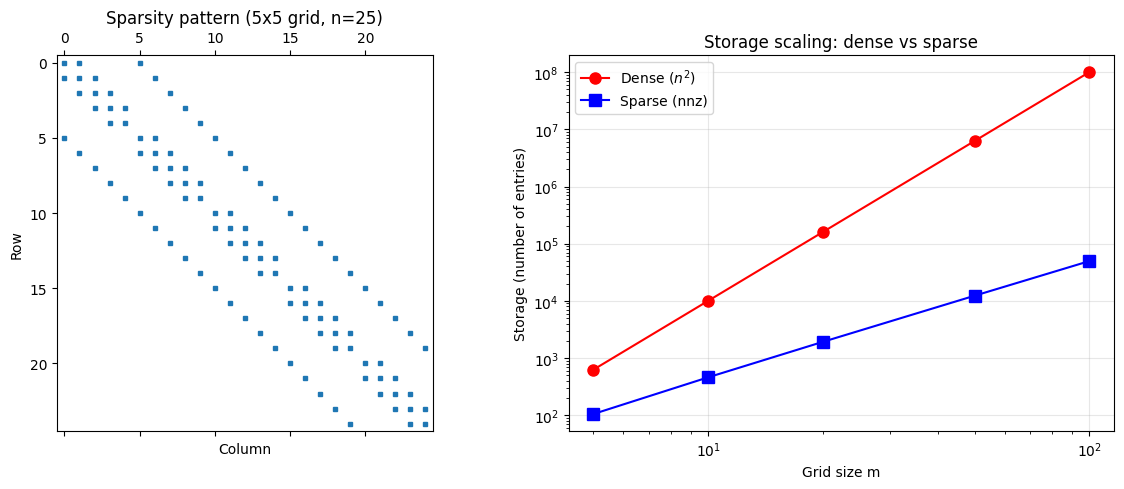


  Grid        n        Dense       Sparse    Ratio
--------------------------------------------------
5x  5       25          625          105        6x
10x 10      100       10,000          460       22x
20x 20      400      160,000        1,920       83x
50x 50     2500    6,250,000       12,300      508x
100x100    10000  100,000,000       49,600     2016x


In [7]:
# Visualize the sparsity pattern
A_dense = coo_lap.to_dense()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Spy plot
axes[0].spy(A_dense, markersize=3)
axes[0].set_title(f"Sparsity pattern ({m}x{m} grid, n={n})")
axes[0].set_xlabel("Column")
axes[0].set_ylabel("Row")

# Scaling comparison
grid_sizes = [5, 10, 20, 50, 100]
dense_storage = []
sparse_storage = []

for m in grid_sizes:
    n = m * m
    nnz = 5 * n - 4 * m  # approximate nnz for 2D Laplacian
    dense_storage.append(n * n)
    sparse_storage.append(nnz)

axes[1].loglog(grid_sizes, dense_storage, 'ro-', label='Dense ($n^2$)', markersize=8)
axes[1].loglog(grid_sizes, sparse_storage, 'bs-', label='Sparse (nnz)', markersize=8)
axes[1].set_xlabel('Grid size m')
axes[1].set_ylabel('Storage (number of entries)')
axes[1].set_title('Storage scaling: dense vs sparse')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print the comparison
print(f"\n{'Grid':>6} {'n':>8} {'Dense':>12} {'Sparse':>12} {'Ratio':>8}")
print("-" * 50)
for m, ds, ss in zip(grid_sizes, dense_storage, sparse_storage):
    print(f"{m}x{m:>3} {m*m:>8} {ds:>12,} {ss:>12,} {ds/ss:>8.0f}x")

## Sparse Matrix-Vector Product

The most basic sparse operation. Dense matvec is $O(n^2)$; sparse matvec is $O(\text{nnz})$.

In [8]:
import time

# Compare dense vs sparse matvec
m = 30
n = m * m  # 900
coo_big = laplacian_2d(m)
csc_big = coo_to_csc(coo_big)
A_big = coo_big.to_dense()
x = np.random.randn(n)

# Dense
t0 = time.perf_counter()
for _ in range(100):
    y_dense = A_big @ x
t_dense = (time.perf_counter() - t0) / 100

# Sparse (our CSC)
t0 = time.perf_counter()
for _ in range(100):
    y_sparse = csc_big.matvec(x)
t_sparse = (time.perf_counter() - t0) / 100

print(f"n = {n}, nnz = {csc_big.nnz}, density = {csc_big.nnz/(n*n):.2%}")
print(f"Dense matvec:  {t_dense*1e6:.0f} us")
print(f"Sparse matvec: {t_sparse*1e6:.0f} us")
print(f"Match: {np.allclose(y_dense, y_sparse)}")

n = 900, nnz = 4380, density = 0.54%


Dense matvec:  297 us
Sparse matvec: 1773 us
Match: True


## Symmetric Storage: Upper Triangle Only

For symmetric matrices, we only need to store the upper (or lower) triangle. ripopt uses **upper triangle COO** (where $\text{row} \leq \text{col}$) for its `SparseSymmetricMatrix`.

This halves storage and avoids redundancy.

In [9]:
class SymCooMatrix:
    """Symmetric COO storing only upper triangle (row <= col)."""
    
    def __init__(self, n):
        self.n = n
        self.rows = []
        self.cols = []
        self.vals = []
    
    def add(self, i, j, v):
        if i > j:
            i, j = j, i  # ensure upper triangle
        self.rows.append(i)
        self.cols.append(j)
        self.vals.append(v)
    
    @property
    def nnz(self):
        return len(self.vals)
    
    def sym_matvec(self, x):
        """Compute y = A @ x using only upper triangle."""
        y = np.zeros(self.n)
        for i, j, v in zip(self.rows, self.cols, self.vals):
            y[i] += v * x[j]
            if i != j:
                y[j] += v * x[i]  # symmetric contribution
        return y


# Compare full COO vs symmetric COO
m = 10
n = m * m
coo_full = laplacian_2d(m)

# Build symmetric version (upper triangle only)
sym_coo = SymCooMatrix(n)
for i, j, v in zip(coo_full.rows, coo_full.cols, coo_full.vals):
    if i <= j:
        sym_coo.add(i, j, v)

print(f"Full COO:      {coo_full.nnz} entries")
print(f"Symmetric COO: {sym_coo.nnz} entries ({sym_coo.nnz/coo_full.nnz:.0%} of full)")

# Verify matvec gives the same result
x = np.random.randn(n)
y_full = coo_full.to_dense() @ x
y_sym = sym_coo.sym_matvec(x)
print(f"Matvec matches: {np.allclose(y_full, y_sym)}")

Full COO:      460 entries
Symmetric COO: 280 entries (61% of full)
Matvec matches: True


## The Fill-In Problem: Why We Can't Just Run LDL^T on Sparse Matrices

Here's the catch: even though $A$ is sparse, the factor $L$ may not be. New nonzeros appearing in $L$ that weren't in $A$ are called **fill-in**.

Fill-in depends on the **ordering** of rows and columns. A bad ordering can make $L$ nearly dense; a good ordering keeps it sparse.

In [10]:
from scipy import sparse
from scipy.sparse.linalg import splu

m = 20
n = m * m
coo = laplacian_2d(m)
A_dense = coo.to_dense()

# Natural ordering: just use the matrix as-is
A_scipy = sparse.csc_matrix(A_dense)

# Factor with natural ordering (permc_spec='NATURAL' disables reordering)
lu_natural = splu(A_scipy, permc_spec='NATURAL')
nnz_L_natural = lu_natural.L.nnz

# Factor with AMD ordering (the default)
lu_amd = splu(A_scipy, permc_spec='MMD_ATA')
nnz_L_amd = lu_amd.L.nnz

nnz_A = A_scipy.nnz
print(f"Matrix: {n}x{n}, nnz(A) = {nnz_A}")
print(f"\nNatural ordering: nnz(L) = {nnz_L_natural}  (fill ratio: {nnz_L_natural/nnz_A:.1f}x)")
print(f"AMD ordering:     nnz(L) = {nnz_L_amd}  (fill ratio: {nnz_L_amd/nnz_A:.1f}x)")
print(f"\nAMD reduces fill by {nnz_L_natural/nnz_L_amd:.1f}x")

Matrix: 400x400, nnz(A) = 1920

Natural ordering: nnz(L) = 8019  (fill ratio: 4.2x)
AMD ordering:     nnz(L) = 5049  (fill ratio: 2.6x)

AMD reduces fill by 1.6x


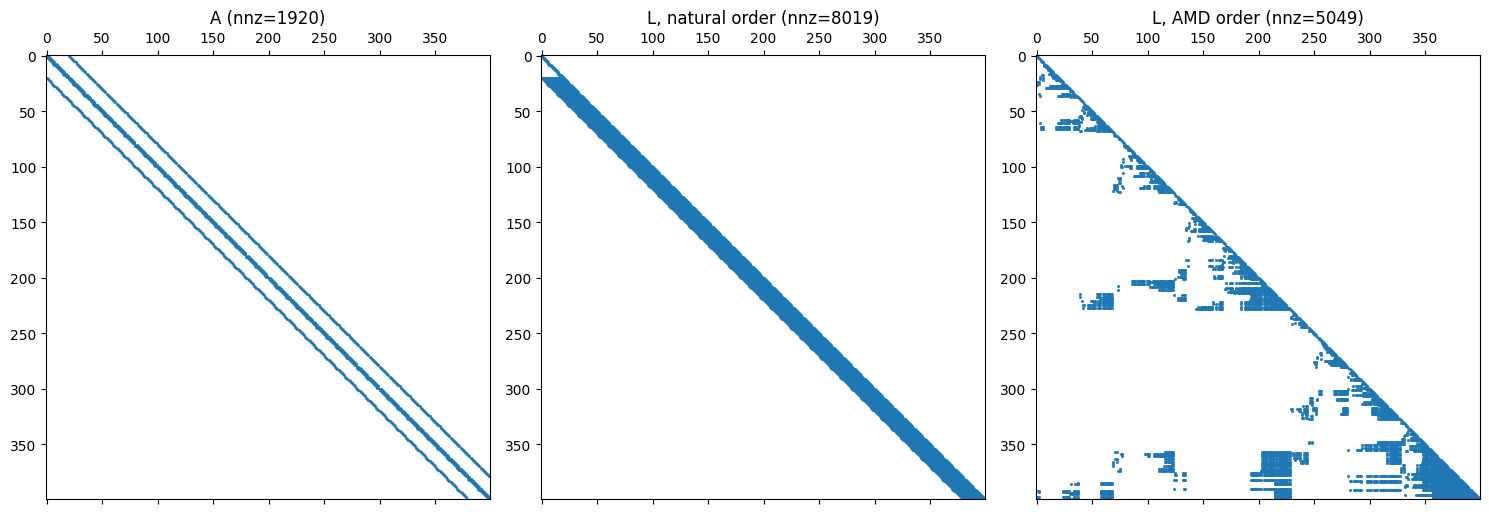

In [11]:
# Visualize fill-in
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].spy(A_scipy, markersize=1)
axes[0].set_title(f"A (nnz={nnz_A})")

axes[1].spy(lu_natural.L, markersize=1)
axes[1].set_title(f"L, natural order (nnz={nnz_L_natural})")

axes[2].spy(lu_amd.L, markersize=1)
axes[2].set_title(f"L, AMD order (nnz={nnz_L_amd})")

plt.tight_layout()
plt.show()

## What We've Learned

1. **COO (coordinate/triplet)** is the assembly format — easy to build, handles duplicates
2. **CSC (compressed sparse column)** is the computation format — efficient column access and matvec
3. For symmetric matrices, storing only the **upper triangle** halves storage
4. Sparse storage scales as $O(\text{nnz})$ vs $O(n^2)$ for dense — critical for large problems
5. **Fill-in** during factorization is the key challenge: the factors can be much denser than $A$
6. **Ordering** (how we number the unknowns) dramatically affects fill-in

## What's Next

In Note 5, we tackle fill-in head-on with **fill-reducing orderings** (AMD) and **elimination trees** — the data structures that let us predict and control the structure of $L$ before we even start factoring.

---

*This is Note 4 in a series building from basic Gaussian elimination to the multifrontal sparse solver used in [ripopt](https://github.com/jkitchin/ripopt).*